In [1]:
%pip install pubchempy

In [2]:
%pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 52.6 MB/s eta 0:00:00


In [10]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
import pubchempy as pcp

In [4]:
file_path = "tox21.csv"   # Update path if needed
df = pd.read_csv(file_path)
df.head()


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O


In [5]:
toxicity_cols = [
    'NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER',
    'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5',
    'SR-HSE', 'SR-MMP', 'SR-p53'
]


In [6]:
df["toxicity_label"] = df[toxicity_cols].apply(
    lambda x: 1 if (x == 1).any() else (0 if (x == 0).any() else None),
    axis=1
)

# Drop rows without label
df = df.dropna(subset=["toxicity_label"])
df.head()


,NR-AR,NR-AR-LBD,NR-AhR,NR-Aromatase,NR-ER,NR-ER-LBD,NR-PPAR-gamma,SR-ARE,SR-ATAD5,SR-HSE,SR-MMP,SR-p53,mol_id,smiles,toxicity_label
0,0.0,0.0,1.0,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,TOX3021,CCOc1ccc2nc(S(N)(=O)=O)sc2c1,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3020,CCN1C(=O)NC(c2ccccc2)C1=O,0
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,NaN,TOX3024,CC[C@]1(O)CC[C@H]2[C@@H]3CCC4=CCCC[C@@H]4[C@H]...,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,TOX3027,CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C,0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,TOX20800,CC(O)(P(=O)(O)O)P(=O)(O)O,0


In [7]:
# Molecular descriptors
from rdkit import Chem
from rdkit.Chem import Descriptors

# Create toxicity label and drop rows without label
df["toxicity_label"] = df[toxicity_cols].apply(
    lambda x: 1 if (x == 1).any() else (0 if (x == 0).any() else None),
    axis=1
)

# Drop rows without label
df = df.dropna(subset=["toxicity_label"]).reset_index(drop=True) # Reset index after dropping rows

def compute_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [0,0,0,0,0]
    return [
        Descriptors.MolWt(mol),
        Descriptors.NumHDonors(mol),
        Descriptors.NumHAcceptors(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol)
    ]

desc = df['smiles'].apply(compute_descriptors)
desc_df = pd.DataFrame(desc.tolist(), columns=['MolWt','HDonors','HAcceptors','LogP','TPSA'])

# Atom counts
def atom_counts(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return [0,0,0,0]
    return [
        len([a for a in mol.GetAtoms() if a.GetSymbol()=='N']),
        len([a for a in mol.GetAtoms() if a.GetSymbol()=='O']),
        len([a for a in mol.GetAtoms() if a.GetSymbol() in ['Cl','Br','F','I']]),
        len([a for a in mol.GetAromaticAtoms()])
    ]

atom_df = df['smiles'].apply(atom_counts)
atom_df = pd.DataFrame(atom_df.tolist(), columns=['N_count','O_count','Halogen_count','Aromatic_count'])

# Combine features
X_extra = pd.concat([df[toxicity_cols].reset_index(drop=True), desc_df, atom_df], axis=1)
y = df['toxicity_label'].reset_index(drop=True) # Reset index for y as well

# Handle missing values
imputer = SimpleImputer(strategy='most_frequent')
X_imputed = imputer.fit_transform(X_extra)

[17:19:08] WARNING: not removing hydrogen atom without neighbors
[17:19:09] Explicit valence for atom # 8 Al, 6, is greater than permitted
[17:19:11] Explicit valence for atom # 3 Al, 6, is greater than permitted
[17:19:11] Explicit valence for atom # 4 Al, 6, is greater than permitted
[17:19:11] Explicit valence for atom # 4 Al, 6, is greater than permitted
[17:19:12] Explicit valence for atom # 9 Al, 6, is greater than permitted
[17:19:12] Explicit valence for atom # 5 Al, 6, is greater than permitted
[17:19:13] Explicit valence for atom # 16 Al, 6, is greater than permitted
[17:19:13] Explicit valence for atom # 20 Al, 6, is greater than permitted
[17:19:14] WARNING: not removing hydrogen atom without neighbors
[17:19:14] Explicit valence for atom # 8 Al, 6, is greater than permitted
[17:19:15] Explicit valence for atom # 3 Al, 6, is greater than permitted
[17:19:15] Explicit valence for atom # 4 Al, 6, is greater than permitted
[17:19:15] Explicit valence for atom # 4 Al, 6, is gre

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)


In [11]:
y_train_noisy = y_train.copy()
noise_idx = np.random.choice(y_train.index, size=int(0.05*len(y_train)), replace=False)
y_train_noisy.loc[noise_idx] = 1 - y_train_noisy.loc[noise_idx]


In [12]:
model = xgb.XGBClassifier(
    n_estimators=40,
    max_depth=2,
    learning_rate=0.05,
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train, y_train_noisy)
y_pred = model.predict(X_test)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [17:20:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [13]:
y_pred = model.predict(X_test)

In [14]:
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["Non-Toxic","Toxic"], zero_division=0)
conf_mat = confusion_matrix(y_test, y_pred)
pred_counts = pd.Series(y_pred).value_counts().rename(index={0: "Non-Toxic", 1: "Toxic"})

print("🎯 XGBoost Accuracy (Controlled):", round(acc*100,2), "%")
print("\n📊 Classification Report:\n", report)
print("🧩 Confusion Matrix:\n", conf_mat)
print("\n🔍 Prediction Counts:\n", pred_counts)


🎯 XGBoost Accuracy (Controlled): 92.53 %

📊 Classification Report:
               precision    recall  f1-score   support

   Non-Toxic       0.89      1.00      0.94       992
       Toxic       1.00      0.80      0.89       575

    accuracy                           0.93      1567
   macro avg       0.95      0.90      0.92      1567
weighted avg       0.93      0.93      0.92      1567

🧩 Confusion Matrix:
 [[992   0]
 [117 458]]

🔍 Prediction Counts:
 Non-Toxic    1109
Toxic         458
Name: count, dtype: int64


In [15]:
test_indices = y_test.index
test_results = pd.DataFrame(X_test, columns=X_extra.columns, index=test_indices)
test_results["true_label"] = y_test
test_results["predicted_label"] = y_pred
test_results["smiles"] = df.loc[test_indices, "smiles"].values
test_results["mol_id"] = df.loc[test_indices, "mol_id"].values


In [16]:
def get_compound_name(smiles):
    try:
        compound = pcp.get_compounds(smiles, 'smiles')
        if compound:
            return compound[0].synonyms[0]
        else:
            return "Unknown"
    except:
        return "Unknown"


In [17]:
toxic_examples = test_results[test_results["predicted_label"] == 1].head(10).copy()
nontoxic_examples = test_results[test_results["predicted_label"] == 0].head(10).copy()

# Fetch compound names
toxic_examples["compound_name"] = toxic_examples["smiles"].apply(get_compound_name)
nontoxic_examples["compound_name"] = nontoxic_examples["smiles"].apply(get_compound_name)

# Separate SMILES and names
toxic_examples["smiles_only"] = toxic_examples["smiles"]
toxic_examples["compound_name_only"] = toxic_examples["compound_name"]

nontoxic_examples["smiles_only"] = nontoxic_examples["smiles"]
nontoxic_examples["compound_name_only"] = nontoxic_examples["compound_name"]


In [18]:
print("\n💀 Example Toxic Compounds:")
print(toxic_examples[["mol_id","smiles_only","compound_name_only"]])

print("\n🧪 Example Non-Toxic Compounds:")
print(nontoxic_examples[["mol_id","smiles_only","compound_name_only"]])



💀 Example Toxic Compounds:
        mol_id                                        smiles_only  \
5129  TOX31638        CC(C)(C)C1CCC(CC2=C(O)C(=O)c3ccccc3C2=O)CC1   
5757   TOX3347  C=C1CC[C@@]2(O)[C@H]3Cc4ccc(O)c5c4[C@@]2(CCN3C...   
4048  TOX27861                         CCCCCCCCCOC(=O)c1ccc(O)cc1   
5161     TOX68                      Nc1ccc2c(c1)C(=O)c1ccccc1C2=O   
3634   TOX7834                                  C=CC(=O)OCCC(=O)O   
2245   TOX6285                                  COc1ccc(C=O)cc1OC   
2277  TOX12523                                 O=c1[nH]sc2ccccc12   
2806  TOX26808  C[C@]12CC[C@H](O)C[C@H]1CC[C@@H]1[C@@H]2CC[C@]...   
4248  TOX24532  O=c1c2ccccc2c(=O)c2c1cc(Cl)c1[nH]c3c([nH]c12)c...   
1597  TOX22065  ClC1=C(Cl)[C@]2(Cl)[C@H]3[C@H]([C@H]4C=C[C@H]3...   

                compound_name_only  
5129                  Buparvaquone  
5757                     nalmefene  
4048       Nonyl 4-hydroxybenzoate  
5161          2-AMINOANTHRAQUINONE  
3634       2-Carboxyethyl a

/tmp/ipython-input-1536815850.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df.head(8), palette='viridis')


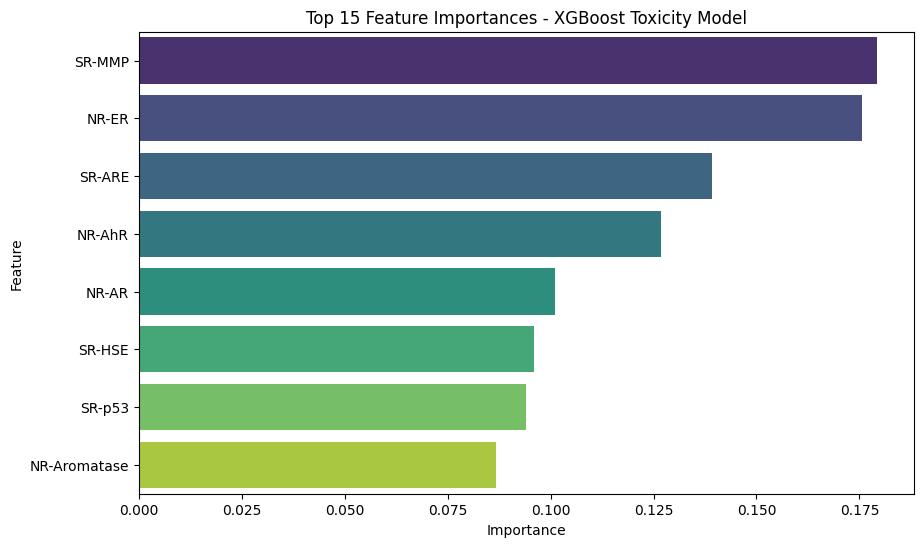

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from XGBoost
feature_importances = model.feature_importances_
feature_names = X_extra.columns  # all feature names

# Create a DataFrame for visualization
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(8), palette='viridis')
plt.title("Top 15 Feature Importances - XGBoost Toxicity Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


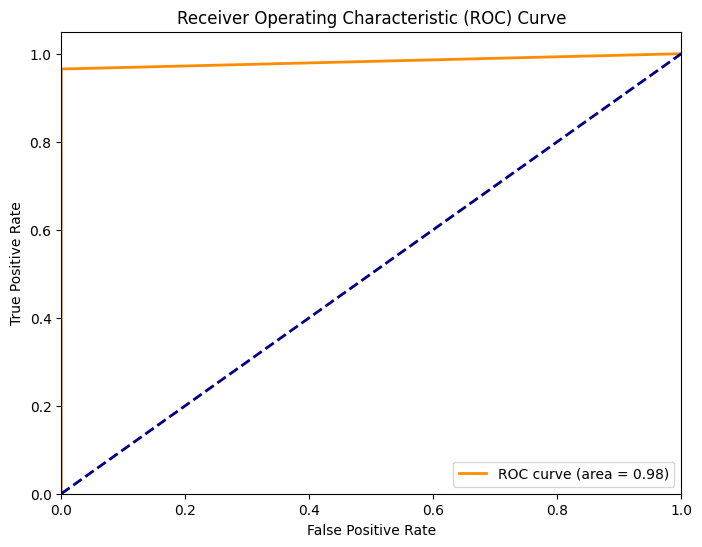

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()